### setup

In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import correlate
from statsmodels.tsa.stattools import grangercausalitytests
import seaborn as sns

models = [
    "gemma3:27b",
    "llama3.3:70b",
    "gpt-oss:120b",
    'gpt-oss:20b',
    "deepseek-r1:70b",
    "qwen3:235b",
    "qwen2.5:72b",
]

In [20]:
db = pd.read_excel("./data/SelfSanctions.xlsx", skiprows=1)
db = db[db[db.columns[3]] == "Switzerland"]
print(len(db))
decision_cols = [i for i in db.columns if "status of decision " in i.lower()]
cols = ["Company name", "Industry", "Description of operations identified"] + decision_cols
db = db[cols]
for c in decision_cols:
    db[c] = db[c].str.replace(" – ", " - ")\
        .str.upper().fillna('')\
        .str.replace("!TO BE VERIFIED", "")\
        .apply(lambda x: x.split(" - ")[0])
db = db.map(lambda x: np.nan if isinstance(x, str) and len(x) == 0 else x)
_cols = [i+"/22" if "new" not in i.lower() else i for i in decision_cols]
_cols = [i.split("decision ")[-1].split("-")[-1] for i in _cols]
dates = pd.to_datetime(_cols, format="%d/%m/%y")
df_ = db.copy()
exit_completed = {}
for c, d in zip(decision_cols, dates):
    v = df_[c].map(lambda x: 1 if "EXIT COMPLETED" in str(x) else (0 if isinstance(x, str) and len(x) > 1 else np.nan))
    exit_completed[d] = v.sum()
exit_completed = pd.DataFrame(list(exit_completed.items()), columns=['Date', 'exit_completed']).set_index('Date')
exit_completed = exit_completed.resample("1M").interpolate()
ec = exit_completed.copy()
ec = ec - ec.shift(1)

c:\chru\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


173


C:\Users\dvalko\AppData\Local\Temp\ipykernel_2272\2085458018.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  exit_completed = exit_completed.resample("1M").interpolate()


In [33]:
df_vv = pd.read_csv("./results/full_agreement_code_vulnerable_victims.csv")
df_vv['datetime'] = pd.to_datetime(df_vv['datetime'])
df_vv['vulnerable_victims'] = df_vv['code_applied']
df_vv.set_index('datetime', inplace=True)

df_ce = pd.read_csv("./results/full_agreement_code_complicit_enablers.csv")
df_ce['datetime'] = pd.to_datetime(df_ce['datetime'])
df_ce['complicit_enablers'] = df_ce['code_applied']
df_ce.set_index('datetime', inplace=True)

df_cl = pd.read_csv("./results/full_agreement_code_conditional_loyalty.csv", parse_dates=["datetime"])
df_cl['datetime'] = pd.to_datetime(df_cl['datetime'])
df_cl['conditional_loyalty'] = df_cl['code_applied']
df_cl.set_index('datetime', inplace=True)

df_as = pd.read_csv("./results/full_agreement_code_adapted_sovereignty.csv", parse_dates=["datetime"])
df_as['datetime'] = pd.to_datetime(df_as['datetime'])
df_as['adapted_sovereignty'] = df_as['code_applied']
df_as.set_index('datetime', inplace=True)

df_ch = pd.concat([df_vv[['vulnerable_victims']], df_ce[['complicit_enablers']]], axis=1)
df_ru = pd.concat([df_cl[['conditional_loyalty']], df_as[['adapted_sovereignty']]], axis=1)

df_ru['count'] = 1
df_ch['count'] = 1

C:\Users\dvalko\AppData\Local\Temp\ipykernel_2272\2188129854.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = df.resample("1M").sum()
C:\Users\dvalko\AppData\Local\Temp\ipykernel_2272\2188129854.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = df.resample("1M").sum()


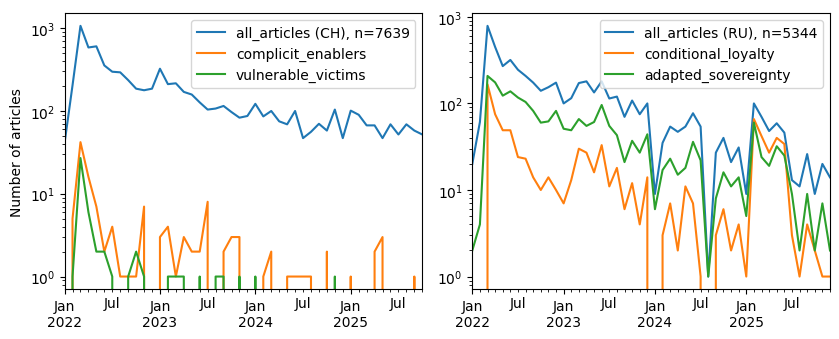

In [37]:
fig = plt.figure(figsize=(8.5, 3.5))
ax1 = fig.add_subplot(1, 2, 1)
df = df_ch.copy()
df = df.resample("1M").sum()
a = f'all_articles (CH), n={len(df_ch)}'
df[a] = df['count']
#df['complicit_enablers'] += 1
#df['vulnerable_victims'] += 1
df[[a, 'complicit_enablers', 
    'vulnerable_victims']].plot(ax=ax1)
ax1.set_xlabel(None)
ax1.set_ylabel('Number of articles')
ax1.set_yscale('log')
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2)
df = df_ru.copy()
df = df.resample("1M").sum()
b = f'all_articles (RU), n={len(df_ru)}'
df[b] = df['count']
#df['complicit_enablers'] += 1
#df['vulnerable_victims'] += 1
df[[b, 'conditional_loyalty', 
    'adapted_sovereignty']].plot(ax=ax2)
ax2.set_xlabel(None)
ax2.set_yscale('log')
ax2.legend()

#ax3 = fig.add_subplot(1, 3, 3)
#exit_completed.plot(ax=ax3)
#ax3.set_xlabel(None)

fig.tight_layout()
fig.savefig('fig01.png', format='png', dpi=600)

In [44]:
def diff_align(x, y):
    x = x - x.shift(1)
    y = y - y.shift(1)
    x_aligned, y_aligned = x.align(y, fill_value=0)
    # return pd.concat([x_aligned, y_aligned], axis=1).fillna(0)
    return x_aligned.fillna(0).values.flatten(), y_aligned.fillna(0).values.flatten()

def cross_corr(x, y):
    x, y = diff_align(x, y)
    x = (x - x.mean()) / x.std()
    y = (y - y.mean()) / y.std()
    #print(len(x), len(y))
    corr = correlate(x, y, mode='full') / len(x)
    lags = np.arange(-len(x)+1, len(x))
    #print(len(corr), len(lags))
    # keep only causal lags: x leads y
    mask = (lags <= 0) & (lags >= -12)
    lags_causal = lags[mask]
    corr_causal = corr[mask]
    best_lag = lags_causal[np.argmax(corr_causal)]
    return lags_causal, corr_causal, best_lag, np.max(np.abs(corr))
    


C:\Users\dvalko\AppData\Local\Temp\ipykernel_2272\2561445856.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  x1 = df_ch['vulnerable_victims'].copy().resample("1M").sum()
C:\Users\dvalko\AppData\Local\Temp\ipykernel_2272\2561445856.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  x2 = df_ch['complicit_enablers'].copy().resample("1M").sum()
C:\Users\dvalko\AppData\Local\Temp\ipykernel_2272\2561445856.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  x1 = df_ru['conditional_loyalty'].copy().resample("1M").sum()
C:\Users\dvalko\AppData\Local\Temp\ipykernel_2272\2561445856.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  x2 = df_ru['adapted_sovereignty'].copy().resample("1M").sum()



Best lag for vulnerable_victims: -6 months with correlation 0.59

Best lag for complicit_enablers: -6 months with correlation 0.52

Best lag for conditional_loyalty: -6 months with correlation 0.44

Best lag for adapted_sovereignty: -10 months with correlation 0.39


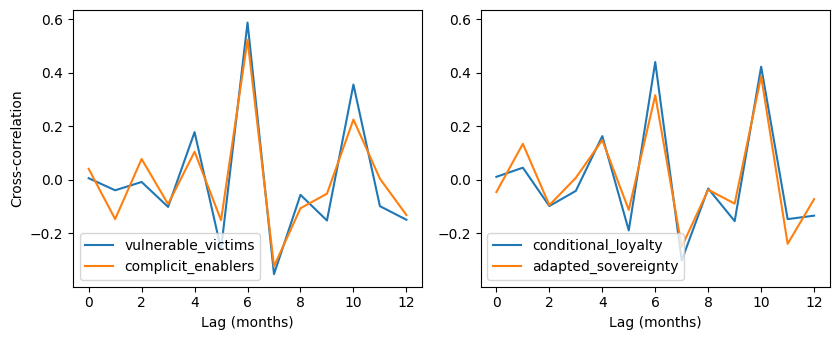

In [60]:
fig = plt.figure(figsize=(8.5, 3.5))
ax1 = fig.add_subplot(1, 2, 1)

x1 = df_ch['vulnerable_victims'].copy().resample("1M").sum()
x2 = df_ch['complicit_enablers'].copy().resample("1M").sum()
y = ec.copy()
lags_causal, corr_causal, best_lag, max_corr = cross_corr(x1, y)
print(f"\nBest lag for vulnerable_victims: {best_lag} months with correlation {max_corr:.2f}")
ax1.plot(lags_causal * -1, corr_causal, label='vulnerable_victims')

lags_causal, corr_causal, best_lag, max_corr = cross_corr(x2, y)
print(f"\nBest lag for complicit_enablers: {best_lag} months with correlation {max_corr:.2f}")
ax1.plot(lags_causal * -1, corr_causal, label='complicit_enablers')

ax1.set_xlabel("Lag (months)")
ax1.set_ylabel("Cross-correlation")
ax1.legend(loc="lower left")

ax2 = fig.add_subplot(1, 2, 2, sharey=ax1)

x1 = df_ru['conditional_loyalty'].copy().resample("1M").sum()
x2 = df_ru['adapted_sovereignty'].copy().resample("1M").sum()
y = ec.copy()
lags_causal, corr_causal, best_lag, max_corr = cross_corr(x1, y)
print(f"\nBest lag for conditional_loyalty: {best_lag} months with correlation {max_corr:.2f}")
ax2.plot(lags_causal * -1, corr_causal, label='conditional_loyalty')

lags_causal, corr_causal, best_lag, max_corr = cross_corr(x2, y)
print(f"\nBest lag for adapted_sovereignty: {best_lag} months with correlation {max_corr:.2f}")
ax2.plot(lags_causal * -1, corr_causal, label='adapted_sovereignty')

ax2.set_xlabel("Lag (months)")
ax2.set_ylabel(None)
ax2.legend(loc="lower left")

fig.tight_layout()
fig.savefig('fig02.png', format='png', dpi=600)


<Axes: >

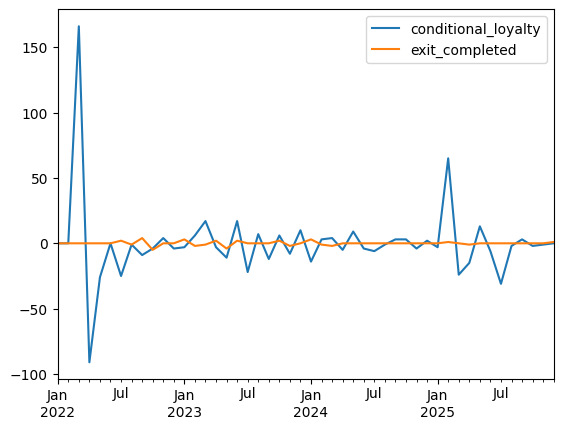

In [23]:
df.plot()